# 05. Pre-modeling EDA -- disability strand



## 0. Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
FIGURE_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [15]:
dis_level = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_MEMS7GR_all_years.csv')
dis_overall = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_dm = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_days_months_all_years.csv')

dis_level['small_cell'] = dis_level['n'] < 30
print('rows:', {'dis_level': len(dis_level), 'dis_overall': len(dis_overall), 'dis_dm': len(dis_dm)})
print('overall small-cell rate:', dis_level['small_cell'].mean().round(3))


rows: {'dis_level': 511488, 'dis_overall': 4096, 'dis_dm': 511488}
overall small-cell rate: 0.693


## 1. Sample size structure


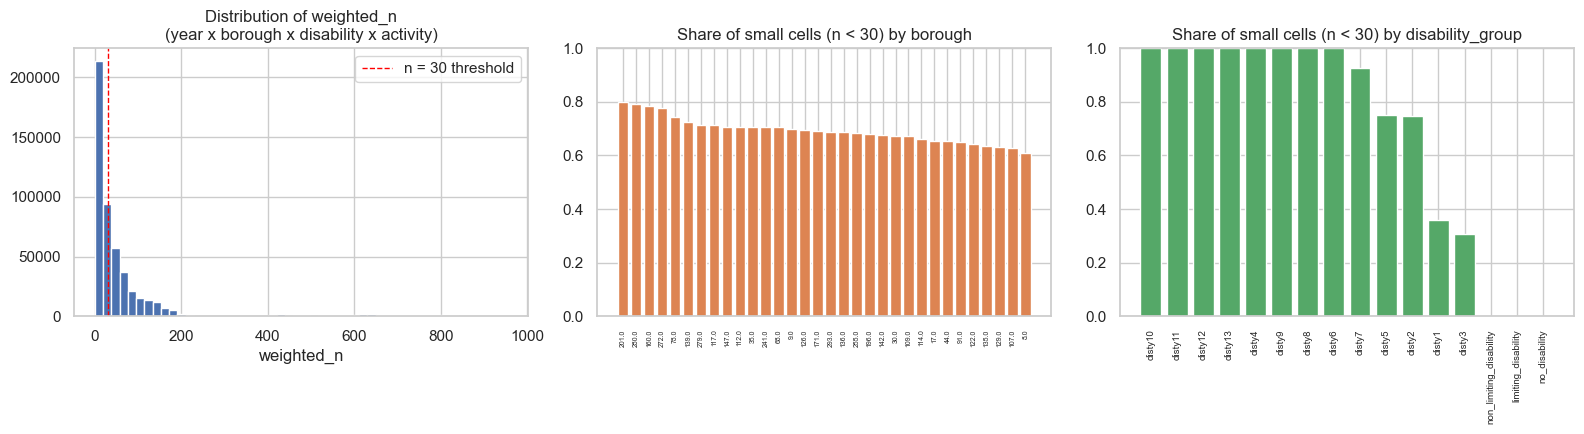

Overall small-cell rate: 69.3%
Boroughs with the highest small-cell rate:
LA_2023
201.0    0.800238
280.0    0.791354
160.0    0.782470
272.0    0.776839
78.0     0.744432
Name: small_cell, dtype: float64
Disability groups with the highest small-cell rate:
disability_group
disty10    1.0
disty11    1.0
disty12    1.0
disty13    1.0
disty4     1.0
Name: small_cell, dtype: float64


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(dis_level['weighted_n'].dropna(), bins=50, color='#4C72B0')
axes[0].set_title('Distribution of weighted_n\n(year x borough x disability x activity)')
axes[0].set_xlabel('weighted_n')
axes[0].axvline(30, color='red', linestyle='--', linewidth=1, label='n = 30 threshold')
axes[0].legend()

by_borough = dis_level.groupby('LA_2023')['small_cell'].mean().sort_values(ascending=False)
axes[1].bar(by_borough.index.astype(str), by_borough.values, color='#DD8452')
axes[1].set_title('Share of small cells (n < 30) by borough')
axes[1].tick_params(axis='x', labelrotation=90, labelsize=5)
axes[1].set_ylim(0, 1)

by_group = dis_level.groupby('disability_group')['small_cell'].mean().sort_values(ascending=False)
axes[2].bar(by_group.index.astype(str), by_group.values, color='#55A868')
axes[2].set_title('Share of small cells (n < 30) by disability_group')
axes[2].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_sample_size_structure.png', dpi=150)
plt.show()

print(f"Overall small-cell rate: {dis_level['small_cell'].mean():.1%}")
print('Boroughs with the highest small-cell rate:')
print(by_borough.head(5))
print('Disability groups with the highest small-cell rate:')
print(by_group.head(5))


## 2. Temporal structure and how predictable the trend actually is


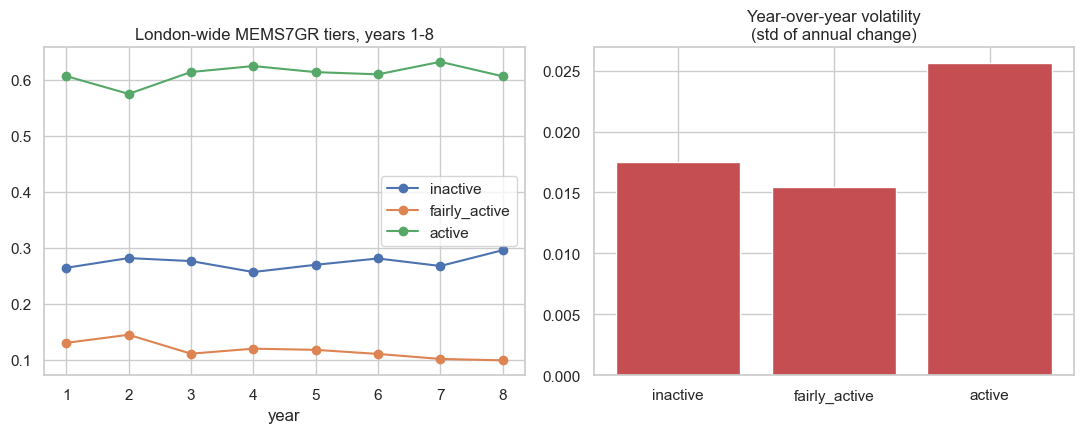

Year-over-year volatility:
inactive         0.0175
fairly_active    0.0155
active           0.0257
dtype: float64


In [17]:
valid_overall = dis_overall.dropna(
    subset=['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']
).query('weighted_n > 0')

london_trend = (
    valid_overall.groupby('year')[['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']]
    .apply(lambda g: pd.Series({
        'inactive': np.average(g['inactive_rate'], weights=g['weighted_n']),
        'fairly_active': np.average(g['fairly_active_rate'], weights=g['weighted_n']),
        'active': np.average(g['active_rate'], weights=g['weighted_n']),
    }))
    .reset_index()
)

year_over_year_change = london_trend[['inactive', 'fairly_active', 'active']].diff().dropna()
volatility = year_over_year_change.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for column in ['inactive', 'fairly_active', 'active']:
    axes[0].plot(london_trend['year'], london_trend[column], marker='o', label=column)
axes[0].set_title('London-wide MEMS7GR tiers, years 1-8')
axes[0].set_xlabel('year')
axes[0].legend()

axes[1].bar(volatility.index, volatility.values, color='#C44E52')
axes[1].set_title('Year-over-year volatility\n(std of annual change)')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_trend_and_volatility.png', dpi=150)
plt.show()

print('Year-over-year volatility:')
print(volatility.round(4))


## 3. Activity participation concentration

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\493892901.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))


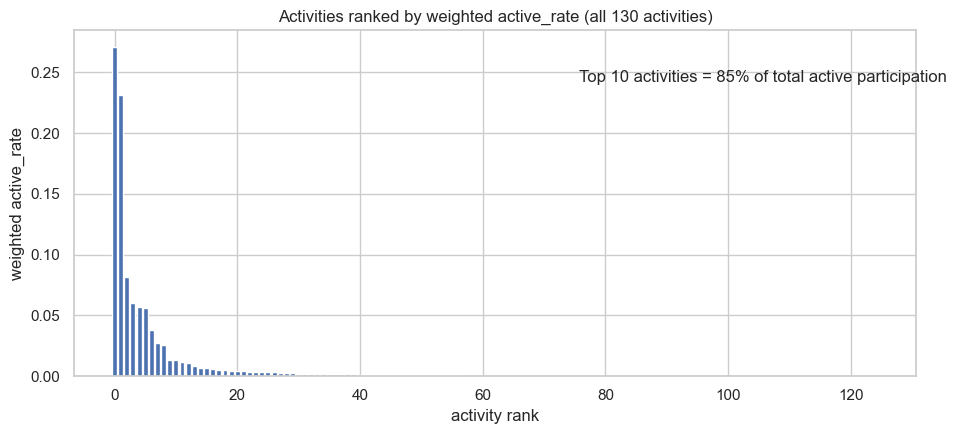

Top 10 activities:
activity
ACTTRAV_C03       0.270924
WALKTRAV_B02      0.230992
GARD_B08          0.082002
RUNJOG_U07        0.060543
CYC_OLD_M02       0.056802
CYCTRAV_B04       0.055964
CYCLEISURE_N01    0.038265
FOOTBALL_F01      0.026994
DANCEOTHER_O01    0.025794
DANCEART_B05      0.013435
dtype: float64


In [18]:
activity_participation = (
    dis_level.dropna(subset=['active_rate', 'weighted_n'])
    .query('weighted_n > 0')
    .groupby('activity')
    .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(len(activity_participation)), activity_participation.values, color='#4C72B0')
ax.set_title('Activities ranked by weighted active_rate (all 130 activities)')
ax.set_xlabel('activity rank')
ax.set_ylabel('weighted active_rate')

top10_share = activity_participation.head(10).sum() / activity_participation.sum()
ax.text(0.6, 0.85, f'Top 10 activities = {top10_share:.0%} of total active participation',
        transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_activity_concentration.png', dpi=150)
plt.show()

print('Top 10 activities:')
print(activity_participation.head(10))


## 4. Disability sub-type co-occurrence (needs the raw individual-level files)


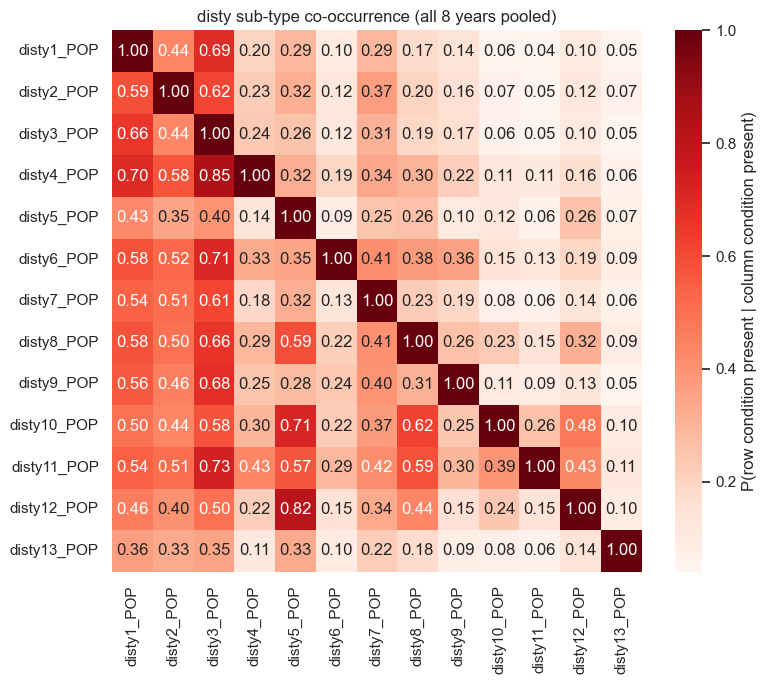

In [19]:
import os

root = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20"
year_files = {
    1: os.path.join(root, "Yifeng Mao", "data", "active_lives_1516_london_125.csv"),
    2: os.path.join(root, "Yifeng Mao", "data", "active_lives_1617_london_125.csv"),
    3: os.path.join(root, "Siyan Xin", "2017~2018", "2017_data_125_activities.csv"),
    4: os.path.join(root, "Siyan Xin", "2018~2019", "2018_data_125_activities.csv"),
    5: os.path.join(root, "Shuhan Zhao", "docs", "1920_london32_stable125.csv"),
    6: os.path.join(root, "Shuhan Zhao", "docs", "2021_london32_stable125.csv"),
    7: os.path.join(root, "Jingyi Hua", "data", "processed", "year7_125activities.csv"),
    8: os.path.join(root, "Jingyi Hua", "data", "processed", "year8_125activities.csv"),
}

disty_cols = [f'disty{i}_POP' for i in range(1, 14)]

co_occurrence_frames = []
for year_number, file_path in year_files.items():
    header = pd.read_csv(file_path, nrows=0).columns
    col_lookup = {c.lower(): c for c in header}
    age_col = col_lookup.get('age16plus')
    if age_col is None:
        raise KeyError(f"Year {year_number} has no Age16plus-like column, check {file_path}")

    year_df = pd.read_csv(file_path, usecols=disty_cols + [age_col])
    year_df = year_df.rename(columns={age_col: 'Age16plus'})
    year_df = year_df[year_df['Age16plus'] == 1]
    co_occurrence_frames.append(year_df[disty_cols])

all_disty = pd.concat(co_occurrence_frames, ignore_index=True)
co_occurrence = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)
for a in disty_cols:
    has_a = all_disty[a] == 1
    for b in disty_cols:
        co_occurrence.loc[a, b] = (all_disty.loc[has_a, b] == 1).mean() if has_a.sum() > 0 else np.nan

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(co_occurrence.astype(float), annot=True, fmt='.2f', cmap='Reds', ax=ax,
            cbar_kws={'label': 'P(row condition present | column condition present)'})
ax.set_title('disty sub-type co-occurrence (all 8 years pooled)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_disty_co_occurrence.png', dpi=150)
plt.show()


## 5. How the three outcome measures relate to each other



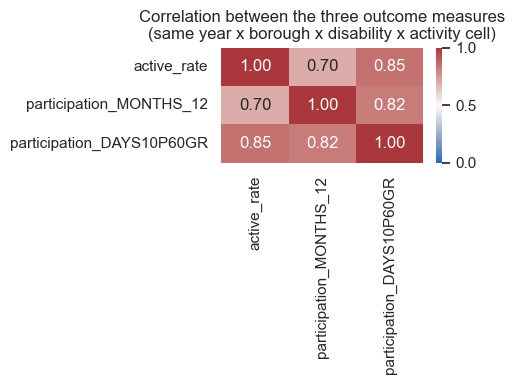

                           active_rate  participation_MONTHS_12  \
active_rate                      1.000                    0.699   
participation_MONTHS_12          0.699                    1.000   
participation_DAYS10P60GR        0.849                    0.821   

                           participation_DAYS10P60GR  
active_rate                                    0.849  
participation_MONTHS_12                        0.821  
participation_DAYS10P60GR                      1.000  


In [8]:
merged_targets = dis_level.merge(
    dis_dm, on=['year', 'LA_2023', 'disability_group', 'activity'], how='inner'
)

correlation_matrix = merged_targets[
    ['active_rate', 'participation_MONTHS_12', 'participation_DAYS10P60GR']
].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation between the three outcome measures\n(same year x borough x disability x activity cell)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_outcome_correlation.png', dpi=150)
plt.show()

print(correlation_matrix.round(3))


## 6. Summary tables


In [9]:
summary_tables_dir = FIGURE_DIR.parent / 'pre_eda_tables'
summary_tables_dir.mkdir(parents=True, exist_ok=True)

by_borough.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_borough.csv')
by_group.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_disability_group.csv')
london_trend.to_csv(summary_tables_dir / 'london_trend_by_year.csv', index=False)
volatility.rename('year_over_year_volatility').to_csv(summary_tables_dir / 'year_over_year_volatility.csv')
activity_participation.rename('weighted_active_rate').to_csv(summary_tables_dir / 'activity_participation_ranked.csv')
co_occurrence.to_csv(summary_tables_dir / 'disty_co_occurrence.csv')
correlation_matrix.to_csv(summary_tables_dir / 'outcome_measure_correlation.csv')

print('Saved tables to', summary_tables_dir)


Saved tables to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_tables


## 7. Observed contrasts (statistical significance)

In [11]:
from scipy import stats

contingency = pd.crosstab(dis_level['LA_2023'], dis_level['small_cell'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n_obs = contingency.sum().sum()
degrees_of_freedom = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * degrees_of_freedom))

print(f'small-cell rate vs borough: chi2={chi2:.1f}, p={p_value:.4g}, Cramér\'s V={cramers_v:.4f}')
print('Cramér\'s V guide: ~0.1 small, ~0.3 medium, ~0.5 large')

small-cell rate vs borough: chi2=5238.6, p=0, Cramér's V=0.1009
Cramér's V guide: ~0.1 small, ~0.3 medium, ~0.5 large


In [12]:
disab3_subset = dis_level[
    dis_level['disability_group'].isin(['limiting_disability', 'non_limiting_disability', 'no_disability'])
]
groups = [g['active_rate'].dropna() for _, g in disab3_subset.groupby('disability_group')]
h_statistic, p_value = stats.kruskal(*groups)

epsilon_squared = (h_statistic - len(groups) + 1) / (len(disab3_subset) - len(groups))
print(f'active_rate across Disab3: H={h_statistic:.1f}, p={p_value:.4g}, epsilon-squared={epsilon_squared:.4f}')
print('epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large')

print(disab3_subset.groupby('disability_group')['active_rate'].median())

active_rate across Disab3: H=4253.8, p=0, epsilon-squared=0.0441
epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large
disability_group
limiting_disability        0.0
no_disability              0.0
non_limiting_disability    0.0
Name: active_rate, dtype: float64


In [13]:
co_occurrence_significance = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)

for a in disty_cols:
    for b in disty_cols:
        if a == b:
            continue
        table = pd.crosstab(all_disty[a], all_disty[b])
        if table.shape == (2, 2):
            _, p_value = stats.fisher_exact(table, alternative='greater')
            co_occurrence_significance.loc[a, b] = p_value

print('Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:')
print(co_occurrence_significance[co_occurrence_significance > 0.05].stack())

Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:
Series([], dtype: float64)


## 8. Activity availability summary

In [8]:
import pandas as pd

PROCESSED_DIR = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed"

path_mems = f"{PROCESSED_DIR}\\RQ3_borough_disability_MEMS7GR_all_years.csv"
path_days_months = f"{PROCESSED_DIR}\\RQ3_borough_disability_days_months_all_years.csv"

df_mems = pd.read_csv(path_mems)
df_dm = pd.read_csv(path_days_months)

print("MEMS7GR list name:", list(df_mems.columns))
print("days_months list name:", list(df_dm.columns))

MEMS7GR list name: ['year', 'LA_2023', 'disability_group', 'activity', 'inactive_rate', 'fairly_active_rate', 'active_rate', 'n', 'weighted_n', 'small_cell_warning']
days_months list name: ['year', 'LA_2023', 'disability_group', 'activity', 'participation_DAYS10P60GR', 'n_DAYS10P60GR', 'weighted_n_DAYS10P60GR', 'participation_MONTHS_12', 'n_MONTHS_12', 'weighted_n_MONTHS_12', 'small_cell_warning_months12', 'small_cell_warning_days10p60gr']


In [10]:
# --- Which years each activity has non-missing MEMS7GR data ---

mems_availability = (
    df_mems.dropna(subset=['active_rate'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('mems7gr_years')
)

print(mems_availability.head())

# --- Which years each activity has MONTHS_12 / DAYS10P60GR data ---

months12_availability = (
    df_dm.dropna(subset=['participation_MONTHS_12'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('months12_years')
)

days_availability = (
    df_dm.dropna(subset=['participation_DAYS10P60GR'])
    .groupby('activity')['year']
    .apply(lambda s: sorted(s.unique()))
    .rename('days10p60gr_years')
)

print(months12_availability.head())
print(days_availability.head())

# --- Merge into one availability summary, also listing the specific missing years ---

ALL_YEARS = set(range(1, 9))
all_activities = sorted(set(df_mems['activity'].unique()) | set(df_dm['activity'].unique()))

records = []
for act in all_activities:
    mems_years = set(mems_availability.get(act, []))
    months_years = set(months12_availability.get(act, []))
    days_years = set(days_availability.get(act, []))

    records.append({
        'activity_suffix': act,
        'activity_level_years_available': len(mems_years),
        'activity_level_missing_years': sorted(ALL_YEARS - mems_years),
        'months12_years_available': len(months_years),
        'months12_missing_years': sorted(ALL_YEARS - months_years),
        'days10p60gr_years_available': len(days_years),
        'days10p60gr_missing_years': sorted(ALL_YEARS - days_years),
        'complete_for_participation': (len(months_years) == 8) and (len(days_years) == 8),
        'complete_for_participation_and_level': (
            len(months_years) == 8 and len(days_years) == 8 and len(mems_years) == 8
        ),
    })

availability_df = pd.DataFrame(records)

out_path = f"{PROCESSED_DIR}\\RQ3_disability_activity_availability_summary.csv"
availability_df.to_csv(out_path, index=False)

print(availability_df['complete_for_participation_and_level'].value_counts())
availability_df.head(10)

activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: mems7gr_years, dtype: object
activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: months12_years, dtype: object
activity
ABSEILING_H03    [1, 2, 3, 4, 5, 6, 7, 8]
ACTTRAV_C03      [1, 2, 3, 4, 5, 6, 7, 8]
AIKIDO_S04       [1, 2, 3, 4, 5, 6, 7, 8]
AIRGUN_S08       [1, 2, 3, 4, 5, 6, 7, 8]
ARCHERY_J01      [1, 2, 3, 4, 5, 6, 7, 8]
Name: days10p60gr_years, dtype: object
complete_for_participation_and_level
True     124
False      1
Name: count, dtype: int64


,activity_suffix,activity_level_years_available,activity_level_missing_years,months12_years_available,months12_missing_years,days10p60gr_years_available,days10p60gr_missing_years,complete_for_participation,complete_for_participation_and_level
0,ABSEILING_H03,8,[],8,[],8,[],True,True
1,ACTTRAV_C03,8,[],8,[],8,[],True,True
2,AIKIDO_S04,8,[],8,[],8,[],True,True
3,AIRGUN_S08,8,[],8,[],8,[],True,True
4,ARCHERY_J01,8,[],8,[],8,[],True,True
5,BADMINTON_G02,8,[],8,[],8,[],True,True
6,BASESOFTBALL_F13,8,[],8,[],8,[],True,True
7,BASKETBALL_F07,8,[],8,[],8,[],True,True
8,BOCCIA_L11,8,[],8,[],8,[],True,True
9,BOULES_L12,8,[],8,[],8,[],True,True


## 9. Add small_cell_warning column to flag unreliable small-n estimates

In [4]:
import pandas as pd

PROCESSED_DIR = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed"

# --- MEMS7GR activity-level table ---
path_mems = f"{PROCESSED_DIR}\\RQ3_borough_disability_MEMS7GR_all_years.csv"
df_mems = pd.read_csv(path_mems)
df_mems['small_cell_warning'] = df_mems['n'] < 30
df_mems.to_csv(path_mems, index=False)
print('mems table small_cell_warning rate:', df_mems['small_cell_warning'].mean().round(3))

# --- overall-level table ---
path_overall = f"{PROCESSED_DIR}\\RQ3_borough_disability_overall_all_years.csv"
df_overall = pd.read_csv(path_overall)
df_overall['small_cell_warning'] = df_overall['n'] < 30
df_overall.to_csv(path_overall, index=False)
print('overall table small_cell_warning rate:', df_overall['small_cell_warning'].mean().round(3))

# --- days_months table ---
path_dm = f"{PROCESSED_DIR}\\RQ3_borough_disability_days_months_all_years.csv"
df_dm = pd.read_csv(path_dm)
df_dm['small_cell_warning_months12'] = df_dm['n_MONTHS_12'] < 30
df_dm['small_cell_warning_days10p60gr'] = df_dm['n_DAYS10P60GR'] < 30
df_dm.to_csv(path_dm, index=False)
print('days_months table months12 small_cell rate:', df_dm['small_cell_warning_months12'].mean().round(3))
print('days_months table days10p60gr small_cell rate:', df_dm['small_cell_warning_days10p60gr'].mean().round(3))

mems table small_cell_warning rate: 0.695
overall table small_cell_warning rate: 0.674
days_months table months12 small_cell rate: 0.712
days_months table days10p60gr small_cell rate: 0.712


## 10. Missingness rate of disability flag variables themselves (all 8 years)

In [21]:
from pathlib import Path

output_path = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\disty_missingness_all_years.txt")
output_path.parent.mkdir(parents=True, exist_ok=True)

disty_cols = [f'disty{i}_POP' for i in range(1, 14)]

with open(output_path, 'w') as f:
    for year_number, file_path in year_files.items():
        header = pd.read_csv(file_path, nrows=0).columns
        col_lookup = {c.lower(): c for c in header}
        age_col = col_lookup.get('age16plus')
        disab3_col = col_lookup.get('disab3')
        if age_col is None or disab3_col is None:
            raise KeyError(f"Year {year_number} missing Age16plus or Disab3 column, check {file_path}")

        cols_to_read = list(dict.fromkeys([age_col, disab3_col] + disty_cols))
        year_df = pd.read_csv(file_path, usecols=cols_to_read)
        year_df = year_df.rename(columns={age_col: 'Age16plus', disab3_col: 'Disab3'})
        year_df = year_df[year_df['Age16plus'] == 1]

        f.write(f"--- Year {year_number} ---\n")
        f.write(f"total respondents: {len(year_df)}\n")

        disab3_missing = year_df['Disab3'].isna().sum()
        f.write(f"Disab3 missing: {disab3_missing} ({disab3_missing / len(year_df):.3%})\n")

        for col in disty_cols:
            n_missing = year_df[col].isna().sum()
            f.write(f"{col} missing: {n_missing} ({n_missing / len(year_df):.3%})\n")
        f.write("\n")

print("saved to", output_path)

saved to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\disty_missingness_all_years.txt


## 11. Quantifying the COVID structural break (Year5-6 vs linear trend)

In [23]:
non_covid_years = london_trend[~london_trend['year'].isin([5, 6])].copy()
covid_years = london_trend[london_trend['year'].isin([5, 6])].copy()

slope, intercept = np.polyfit(non_covid_years['year'], non_covid_years['active'], 1)

london_trend['predicted_active'] = slope * london_trend['year'] + intercept
london_trend['residual'] = london_trend['active'] - london_trend['predicted_active']
london_trend['abs_residual'] = london_trend['residual'].abs()

print("Linear trend fitted on years excluding 5 and 6:")
print(f"slope={slope:.5f}, intercept={intercept:.5f}")
print()
print(london_trend[['year', 'active', 'predicted_active', 'residual', 'abs_residual']])
print()

non_covid_residual_mean = london_trend.loc[~london_trend['year'].isin([5, 6]), 'abs_residual'].mean()
covid_residual_mean = london_trend.loc[london_trend['year'].isin([5, 6]), 'abs_residual'].mean()

print(f"mean abs residual, non-COVID years: {non_covid_residual_mean:.5f}")
print(f"mean abs residual, COVID years (5,6): {covid_residual_mean:.5f}")
print(f"ratio: {covid_residual_mean / non_covid_residual_mean:.2f}x")

Linear trend fitted on years excluding 5 and 6:
slope=0.00331, intercept=0.59573

   year    active  predicted_active  residual  abs_residual
0     1  0.606413          0.599040  0.007374      0.007374
1     2  0.574605          0.602349 -0.027744      0.027744
2     3  0.613710          0.605658  0.008052      0.008052
3     4  0.624361          0.608968  0.015393      0.015393
4     5  0.613516          0.612277  0.001239      0.001239
5     6  0.609562          0.615587 -0.006024      0.006024
6     7  0.631909          0.618896  0.013013      0.013013
7     8  0.606117          0.622206 -0.016088      0.016088

mean abs residual, non-COVID years: 0.01461
mean abs residual, COVID years (5,6): 0.00363
ratio: 0.25x


In [24]:
group_trend = (
    valid_overall.groupby(['year', 'disability_group'])[['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']]
    .apply(lambda g: pd.Series({
        'active': np.average(g['active_rate'], weights=g['weighted_n']),
    }))
    .reset_index()
)

results = []
for group_name, g in group_trend.groupby('disability_group'):
    g = g.sort_values('year')
    non_covid = g[~g['year'].isin([5, 6])]

    if len(non_covid) < 2:
        continue

    slope, intercept = np.polyfit(non_covid['year'], non_covid['active'], 1)
    g = g.copy()
    g['predicted_active'] = slope * g['year'] + intercept
    g['abs_residual'] = (g['active'] - g['predicted_active']).abs()

    non_covid_mean = g.loc[~g['year'].isin([5, 6]), 'abs_residual'].mean()
    covid_mean = g.loc[g['year'].isin([5, 6]), 'abs_residual'].mean()

    results.append({
        'disability_group': group_name,
        'non_covid_mean_abs_residual': non_covid_mean,
        'covid_mean_abs_residual': covid_mean,
        'ratio': covid_mean / non_covid_mean if non_covid_mean > 0 else np.nan,
    })

covid_by_group = pd.DataFrame(results).sort_values('ratio', ascending=False)
print(covid_by_group.round(4).to_string(index=False))

       disability_group  non_covid_mean_abs_residual  covid_mean_abs_residual  ratio
          no_disability                       0.0102                   0.0216 2.1042
                disty10                       0.0263                   0.0364 1.3852
                disty13                       0.0372                   0.0442 1.1900
                 disty8                       0.0363                   0.0373 1.0284
                 disty9                       0.0376                   0.0317 0.8417
                 disty6                       0.0561                   0.0427 0.7603
                 disty4                       0.0439                   0.0311 0.7070
                disty11                       0.0411                   0.0243 0.5918
                 disty2                       0.0266                   0.0138 0.5210
non_limiting_disability                       0.0114                   0.0055 0.4773
                 disty1                       0.0339             

## 12. Lag-1 autocorrelation check

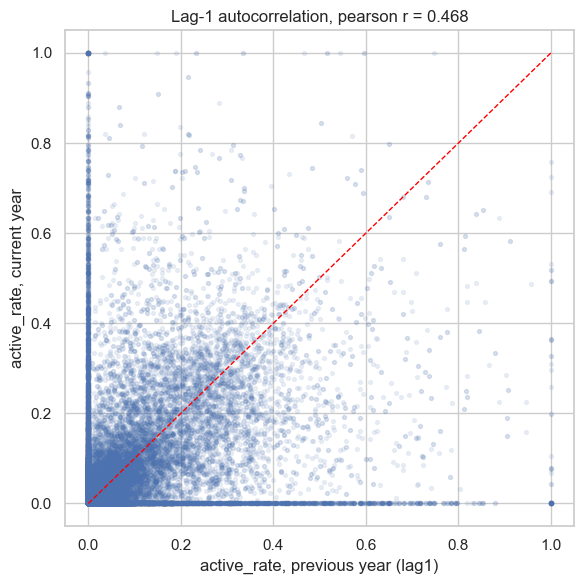

pearson r = 0.4683, p = 0.00e+00, n = 440524


In [25]:
from scipy.stats import pearsonr

panel_keys = ['LA_2023', 'disability_group', 'activity']

lag_check = dis_level.dropna(subset=['active_rate']).sort_values('year').copy()
lag_check['active_rate_lag1'] = lag_check.groupby(panel_keys)['active_rate'].shift(1)
lag_check = lag_check.dropna(subset=['active_rate_lag1'])

r_value, p_value = pearsonr(lag_check['active_rate_lag1'], lag_check['active_rate'])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(lag_check['active_rate_lag1'], lag_check['active_rate'], alpha=0.1, s=8)
ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1)
ax.set_xlabel('active_rate, previous year (lag1)')
ax.set_ylabel('active_rate, current year')
ax.set_title(f'Lag-1 autocorrelation, pearson r = {r_value:.3f}')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_12_lag1_autocorrelation.png', dpi=150)
plt.show()

print(f'pearson r = {r_value:.4f}, p = {p_value:.2e}, n = {len(lag_check)}')

## 13. Disability activity gap over time

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\1763860494.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))


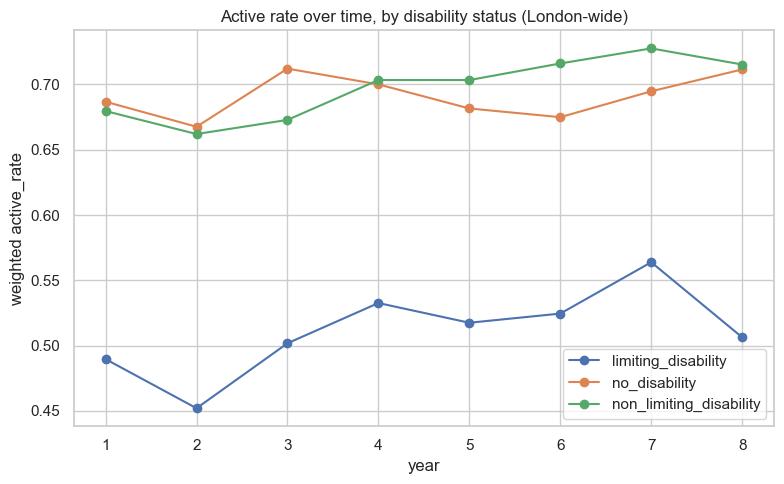

disability_group  limiting_disability  no_disability  non_limiting_disability  \
year                                                                            
1                              0.4897         0.6868                   0.6796   
2                              0.4521         0.6676                   0.6620   
3                              0.5018         0.7121                   0.6729   
4                              0.5326         0.7001                   0.7034   
5                              0.5175         0.6816                   0.7034   
6                              0.5246         0.6750                   0.7161   
7                              0.5639         0.6948                   0.7276   
8                              0.5064         0.7115                   0.7153   

disability_group  gap_limiting_vs_no_disability  
year                                             
1                                        0.1971  
2                                      

In [26]:
disab3_trend = (
    valid_overall[valid_overall['disability_group'].isin(
        ['limiting_disability', 'non_limiting_disability', 'no_disability']
    )]
    .groupby(['year', 'disability_group'])
    .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
    .rename('active')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
for group_name, g in disab3_trend.groupby('disability_group'):
    g = g.sort_values('year')
    ax.plot(g['year'], g['active'], marker='o', label=group_name)

ax.set_xlabel('year')
ax.set_ylabel('weighted active_rate')
ax.set_title('Active rate over time, by disability status (London-wide)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_13_disability_gap_trend.png', dpi=150)
plt.show()

gap = disab3_trend.pivot(index='year', columns='disability_group', values='active')
gap['gap_limiting_vs_no_disability'] = gap['no_disability'] - gap['limiting_disability']
print(gap.round(4))

## 14. Spatial heterogeneity across London boroughs

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\162956161.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11056\162956161.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, vert=True)


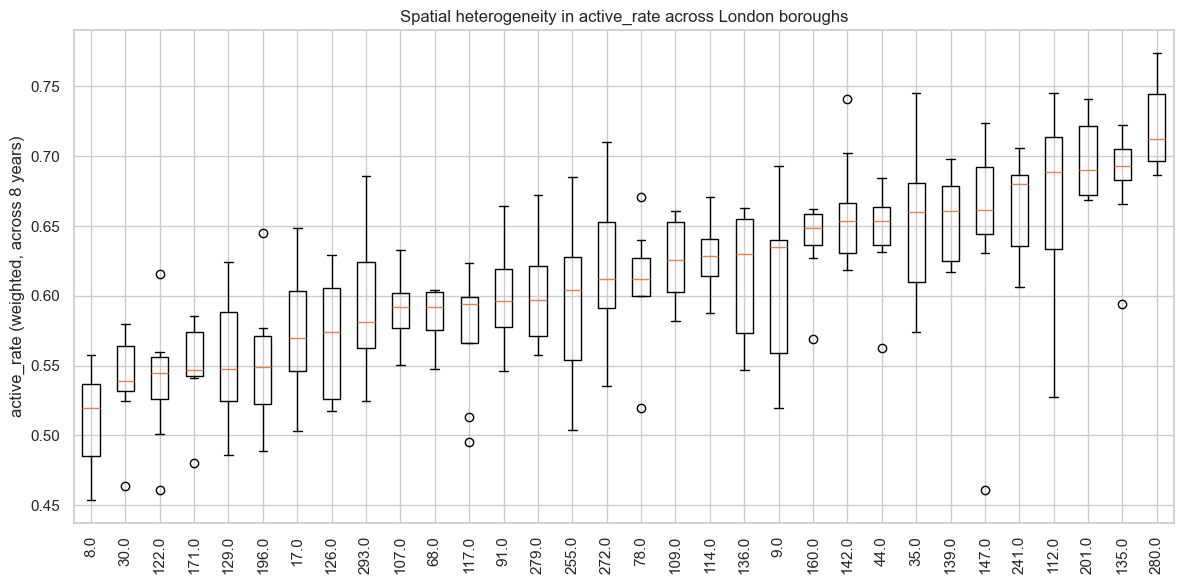

         median     std
LA_2023                
8.0      0.5199  0.0365
30.0     0.5387  0.0359
122.0    0.5448  0.0452
171.0    0.5471  0.0329
129.0    0.5475  0.0487
196.0    0.5488  0.0486
17.0     0.5696  0.0492
126.0    0.5740  0.0456
293.0    0.5813  0.0523
107.0    0.5918  0.0249
68.0     0.5920  0.0205
117.0    0.5941  0.0455
91.0     0.5964  0.0403
279.0    0.5971  0.0420
255.0    0.6042  0.0639
272.0    0.6122  0.0545
78.0     0.6123  0.0436
109.0    0.6258  0.0311
114.0    0.6283  0.0265
136.0    0.6301  0.0476
9.0      0.6347  0.0609
160.0    0.6485  0.0306
142.0    0.6538  0.0421
44.0     0.6538  0.0376
35.0     0.6598  0.0561
139.0    0.6609  0.0316
147.0    0.6618  0.0824
241.0    0.6798  0.0366
112.0    0.6889  0.0766
201.0    0.6903  0.0311
135.0    0.6933  0.0409
280.0    0.7126  0.0337

range across boroughs (median max - median min): 0.1928


In [28]:
borough_trend = (
    valid_overall.groupby(['LA_2023', 'year'])
    .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
    .rename('active')
    .reset_index()
)

order = borough_trend.groupby('LA_2023')['active'].median().sort_values().index

fig, ax = plt.subplots(figsize=(12, 6))
data = [borough_trend.loc[borough_trend['LA_2023'] == b, 'active'].values for b in order]
ax.boxplot(data, labels=order, vert=True)
ax.set_xticklabels(order, rotation=90)
ax.set_ylabel('active_rate (weighted, across 8 years)')
ax.set_title('Spatial heterogeneity in active_rate across London boroughs')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_14_borough_boxplot.png', dpi=150)
plt.show()

borough_summary = borough_trend.groupby('LA_2023')['active'].agg(['median', 'std']).sort_values('median')
print(borough_summary.round(4))
print()
print('range across boroughs (median max - median min):', round(borough_summary['median'].max() - borough_summary['median'].min(), 4))